In [686]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# 1-Qubit case

In [687]:
class LSZ_experiment():

    def __init__(self, alpha, epsilon, total_time, wait_time, max_s):
        '''
        Params:
        epsilon: Coefficient of X Hamiltonian
        alpha: Coefficient of target Hamiltonian
        total_time: Total time of the algorithm
        wait_time: Waiting time in the middle of the LSZ algorithm (0 if just doing LZ)
        max_s: maximum of s parameter. Will control slope of schedule
        '''

        self.e = epsilon
        self.a = alpha

        self.to =  0
        self.tf = total_time
        self.tw = wait_time

        assert wait_time < total_time, f"Wait time ({wait_time}) has to be lower than total time ({total_time})"

        self.tr = (self.tf - self.tw)/2

        self.s_max = max_s
        self.slope = self.s_max/self.tr

        self.npsx = np.array([[0, 1], [1, 0]])
        self.npsz = np.array([[1, 0], [0, -1]])

        self.qtsx = qt.sigmax()
        self.qtsz = qt.sigmaz()

        self.ket0 = qt.basis(2, 0)
        self.ket1 = qt.basis(2, 1)

    
    def trapezoid_s(self, t):
        return np.minimum(self.s_max, self.slope * np.minimum(t, self.tf - t))

    def H_numpy(self, t):
        #Choose mode
        # s = self.trapezoid_s(t)
        s = self.s_max - self.trapezoid_s(t)
        return self.e*self.npsx + self.a*s*self.npsz
    
    def H_qutip(self):
        # s = lambda t, args: self.trapezoid_s(t)
        def s(t, args):
            return self.s_max - self.trapezoid_s(t)
        
        H_epsilon = self.e*self.qtsx
        H_alpha = self.a*self.qtsz

        H = [H_epsilon, [H_alpha, s]]

        return H
    
    def show_schedule(self, n_steps):
        t_list = np.linspace(self.to, self.tf, n_steps)
        s_list = np.zeros(len(t_list))

        for i,t in enumerate(t_list):
            s_list[i] = self.trapezoid_s(t)
        
        return t_list, s_list
    
    def show_spectrum(self, n_steps):
        t_list = np.linspace(self.to, self.tf, n_steps)
        eg_val_list = []
        eg_vec_list = []

       #Diagonalize for each time step 
        for i,t in enumerate(t_list):
            H = self.H_numpy(t)
            egvals, egvecs = np.linalg.eigh(H)

            eg_val_list.append(egvals)
            eg_vec_list.append(egvecs)

        return t_list, eg_val_list, eg_vec_list
    

    def time_evolution(self, n_steps):
        t_list = np.linspace(self.to, self.tf, n_steps)

        #Calculate ground state of H at time 0
        H_i = self.H_numpy(0)
        eigvals_i, eigvecs_i = np.linalg.eigh(H_i)
        #psi0 = eigvecs_i[:, 0][0]*self.ket0 + eigvecs_i[:, 0][1]*self.ket1
        psi0 = eigvecs_i[0][0]*self.ket0 + eigvecs_i[0][1]*self.ket1

        #Initialize qutip Hamiltonian
        H = self.H_qutip()

        #Time evolution
        return qt.sesolve(H, psi0, t_list)
    
    def LZ_transition(self, sim_res):

        final_state = sim_res.states[-1]

        H_f = self.H_numpy(self.tf)
        eigvals_f, eigvecs_f = np.linalg.eigh(H_f)

        dot_c = np.dot(final_state.full().flatten(), eigvecs_f[0])
        dot_e = np.dot(final_state.full().flatten(), eigvecs_f[1])

        pc = dot_c*dot_c.conj()
        pe = dot_e*dot_e.conj()

        return pc, pe
                    




In [688]:
#These two control the relative size of the minimum and maximum gaps
alpha = 5
epsilon = 1

#Wait time will also control speed of the ramp
total_time = 1
wait_time = 0

#This also controls relative size of min gap. We can control it with either parameter
max_s = 1

n_steps = 1001

test_lsz = LSZ_experiment(alpha, epsilon, total_time, wait_time, max_s)

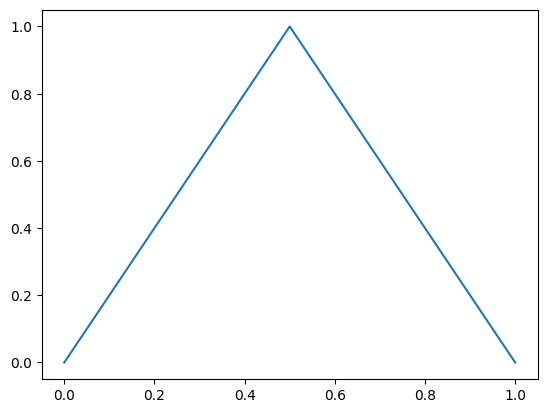

In [689]:
t_list, s_list = test_lsz.show_schedule(n_steps)

plt.plot(t_list, s_list)

In [690]:
t_list, egvals, egvecs = test_lsz.show_spectrum(n_steps)

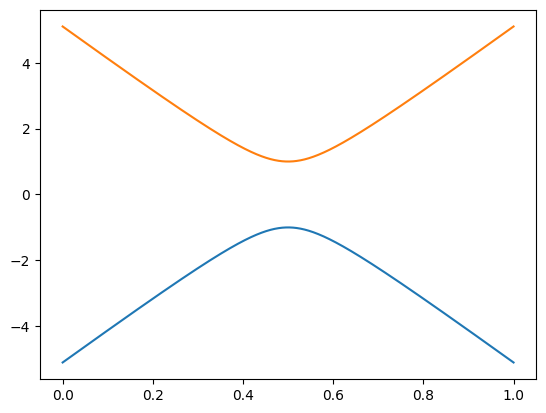

In [691]:
plt.plot(t_list, egvals)

In [692]:
result = test_lsz.time_evolution(n_steps)

In [693]:
pc, pe = test_lsz.LZ_transition(result)

print(np.real(pc), np.real(pe))

0.8602531503665444 0.13974684963345532


In [694]:
epsilon = 1

total_time = 1
wait_time = 0.99

max_s = 1

n_steps = 1001

alpha_list = np.linspace(0.001, 10, 101)
pc_list = []
pe_list = []

for alpha in alpha_list:
    experiment =LSZ_experiment(alpha, epsilon, total_time, wait_time, max_s)

    result = experiment.time_evolution(n_steps)

    pc, pe = experiment.LZ_transition(result)

    pc_list.append(np.real(pc))
    pe_list.append(np.real(pe))

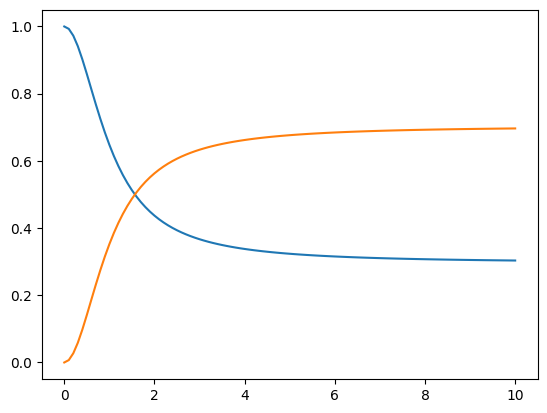

In [695]:
plt.plot(alpha_list, pc_list)
plt.plot(alpha_list, pe_list)